In [1]:
%pip install pandas numpy matplotlib pyfixest

  Using cached scipy-1.15.3-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached scipy-1.15.3-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.3 MB)
  Attempting uninstall: scipy
    Found existing installation: scipy 1.17.1
    Uninstalling scipy-1.17.1:
      Successfully uninstalled scipy-1.17.1
Note: you may need to restart the kernel to use updated packages.


# Imports

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import pyfixest as pf


import os

folder_path = "../output/simulations_revision_regression"

# Tests


In [18]:
test = 1 
panel_1 = pd.read_csv(os.path.join(folder_path,f"panel_data_s{test}1.csv"))
panel_1

,firm_id,year,K,D,D_half,sigma,sigma_half,log_D,log_D_half,log_sigma,log_sigma_half,I,Delta_I,I_total,I_rate,profit,E_last_semester,E_beginning,E_half
0,1,1,1.000000,416.509921,470.498245,0.089538,0.084933,6.031910,6.153792,-2.413088,-2.465893,0.0,0.0,0.0,0.0,0.574549,NaN,0.0,0.0
1,1,2,0.900000,445.039937,530.547699,0.084856,0.102145,6.098164,6.273910,-2.466803,-2.281361,0.0,0.0,0.0,0.0,0.619380,0.0,0.0,0.0
2,1,3,0.810000,538.447284,490.037841,0.108559,0.105278,6.288690,6.194483,-2.220459,-2.251154,0.0,0.0,0.0,0.0,0.642966,0.0,0.0,0.0
3,1,4,0.729000,605.122641,590.808891,0.086492,0.087645,6.405431,6.381493,-2.447706,-2.434459,0.0,0.0,0.0,0.0,0.728971,0.0,0.0,0.0
4,1,5,0.656100,528.027497,515.502293,0.113812,0.088728,6.269148,6.245142,-2.173210,-2.422181,0.0,0.0,0.0,0.0,0.638030,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,100,9996,1.363302,398.174478,488.287440,0.115081,0.100477,5.986890,6.190904,-2.162115,-2.297827,0.0,0.0,0.0,0.0,0.591963,0.0,0.0,0.0
999996,100,9997,1.226972,479.081041,450.178481,0.111600,0.102094,6.171870,6.109644,-2.192832,-2.281864,0.0,0.0,0.0,0.0,0.611491,0.0,0.0,0.0
999997,100,9998,1.104275,523.289265,484.665406,0.096374,0.105611,6.260134,6.183459,-2.339520,-2.247992,0.0,0.0,0.0,0.0,0.651105,0.0,0.0,0.0
999998,100,9999,0.993847,542.118487,472.532422,0.110244,0.083708,6.295485,6.158106,-2.205057,-2.480424,0.0,0.0,0.0,0.0,0.648104,0.0,0.0,0.0


In [24]:
panel_1['Rev_0'] = np.log(panel_1['E_beginning'])-np.log(panel_1['E_last_semester'])
panel_1['Rev_1'] = np.log(panel_1['E_half'])-np.log(panel_1['E_beginning'])
pf.feols("I_rate ~ sigma_half  + D_half | firm_id",panel_1.query('year > 200')).summary()

/opt/python/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


###

Estimation:  OLS
Dep. var.: I_rate, Fixed effects: firm_id
Inference:  iid
Observations:  980000

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| sigma_half    |     -0.021 |        0.134 |    -0.157 |      0.875 | -0.284 |   0.242 |
| D_half        |      0.003 |        0.000 |   119.531 |      0.000 |  0.003 |   0.003 |
---
RMSE: 1.347 R2: 0.014 R2 Within: 0.014 


<Axes: xlabel='year'>

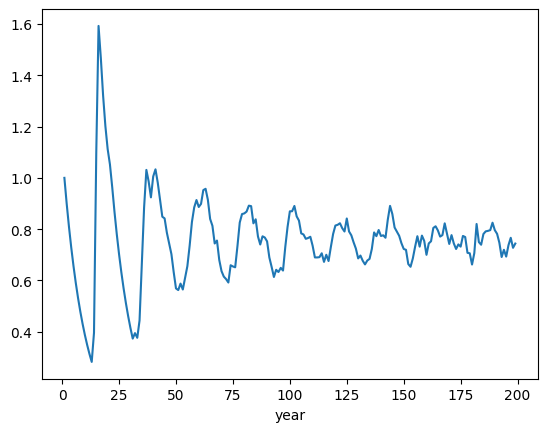

In [21]:
panel_1.query('year <200').groupby(['year']).K.mean().plot()